# Testing the Waveform Generator

This noteboook will serve as a quick way of testing if the WaveformModule for 1PAT1R is consistently passing what it should be to the amplitude, summation and trajectory modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux

In [2]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 1e6/4      # secondary mass [solar masses]
a  = 0.0       # primary spin chi1 (dimensionless)
p0 = 12.0      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.0           # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [3]:

# --- Generate waveform ---
WF1PAT1R = Waveform1PAT1R()
h1PAT1R = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T)


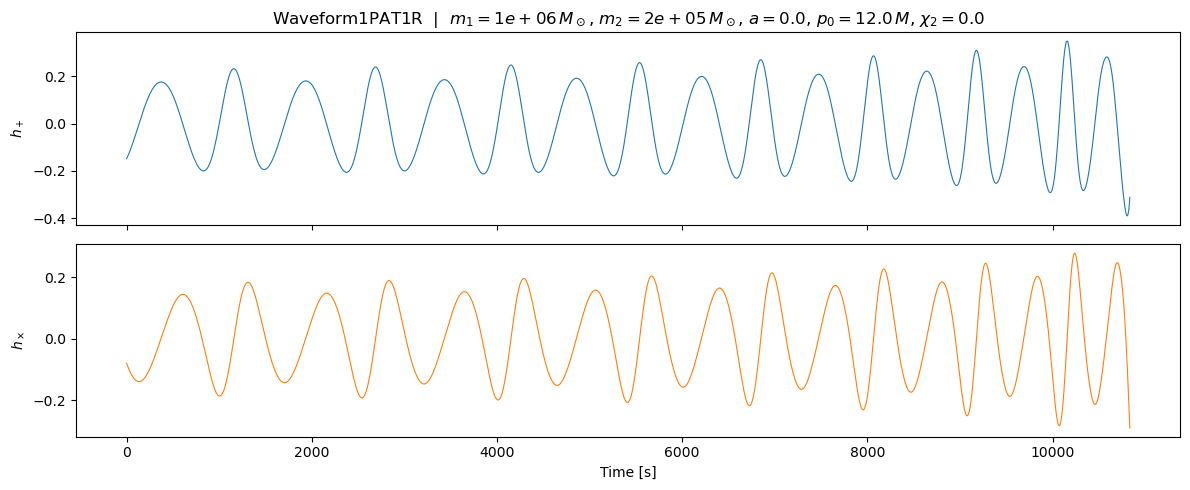

In [4]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t1PA, h1PAT1R.real, lw=0.8)
axes[0].set_ylabel(r"$h_+$")
axes[0].set_title(
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$a={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

axes[1].plot(t1PA, -h1PAT1R.imag, lw=0.8, color="C1")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

In [5]:
# --- Generate comparison waveform ---
WFKerr0PA = FastKerrEccentricEquatorialFlux()
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)

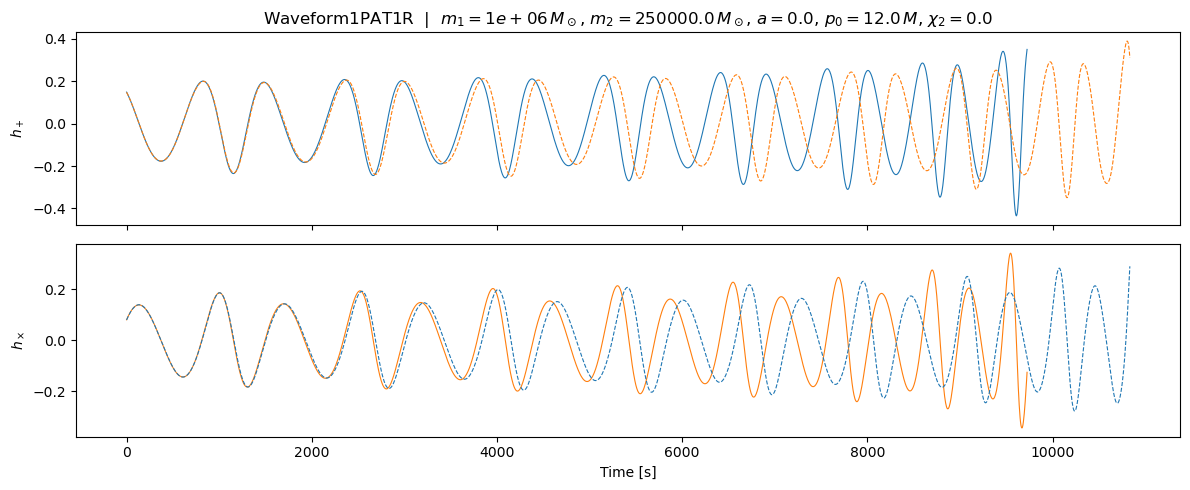

In [6]:
tKerr = np.arange(len(hKerr)) * dt  # time array in seconds
# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(tKerr, hKerr.real, lw=0.8)
axes[0].plot(t1PA, -h1PAT1R.real, lw=0.8, ls="--", color="C1")
axes[0].set_ylabel(r"$h_+$")
axes[0].set_title(
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2}\,M_\odot$, "
    rf"$a={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

axes[1].plot(tKerr, -hKerr.imag, lw=0.8, color="C1")
axes[1].plot(t1PA, h1PAT1R.imag, lw=0.8, ls="--", color="C0")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

So comparing just 0PA non-spinning WFs, it looks like there is a missing factor of $\nu$. Also it looks like our waveforms have the wrong sign compared to FEWv2.0

In [ ]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R

In [8]:
from few.trajectory.inspiral import EMRIInspiral

# Trajectory1PAT1R is an ODE RHS — it must be driven by EMRIInspiral
traj1PA = EMRIInspiral(func=Trajectory1PAT1R)

# EMRIInspiral expects: (m1, m2, a, p0, e0, xI, *extra_args, T=, dt=)
#   a    = chi1 (primary spin)
#   e0   = 0.0  (circular)
#   xI   = 1.0  (equatorial prograde)
#   chi2 = first extra arg -> additional_args[0] in Trajectory1PAT1R
t, p, e, xI_traj, Phi_phi, Phi_theta, Phi_r = traj1PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,     # extra arg -> additional_args[0]
    T=T,
    dt=dt,
)

print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")


Trajectory length: 49 points
p: 12.0000 -> 6.2500 M
Phi_phi: 0.0000 -> 53.9500 rad


In [10]:
from few.trajectory.ode.flux import KerrEccEqFlux

In [11]:
traj0PA = EMRIInspiral(func=KerrEccEqFlux)


t2, p2, e2, xI_traj, Phi_phi2, Phi_theta2, Phi_r2 = traj0PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    T=T,
    dt=dt,
)

print(f"Trajectory length: {len(t2)} points")
print(f"p: {p2[0]:.4f} -> {p2[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi2[0]:.4f} -> {Phi_phi2[-1]:.4f} rad")

Trajectory length: 81 points
p: 12.0000 -> 6.0020 M
Phi_phi: 0.0000 -> 49.6544 rad


Trajectory length: 49 points
p: 12.0000 -> 6.2500 M
Phi_phi: 0.0000 -> 53.9500 rad


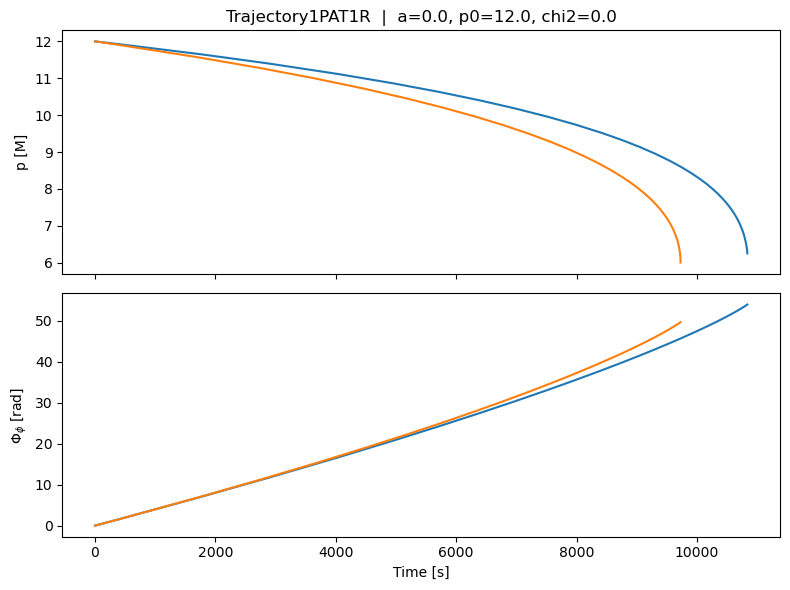

In [13]:
print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t, p)
axes[0].plot(t2, p2)
axes[0].set_ylabel("p [M]")
axes[0].set_title(f"Trajectory1PAT1R  |  a={a}, p0={p0}, chi2={chi2}")
axes[1].plot(t, Phi_phi)
axes[1].plot(t2, Phi_phi2)
axes[1].set_ylabel(r"$\Phi_\phi$ [rad]")
axes[1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()
